# Non-Parametric Density Estimation: Parzen Window and K-Nearest Neighbors (KNN)

This notebook presents the non-parametric density estimation for samples generated from a uniform distribution $U(-1, 1)$ using two main approaches:
1. **Parzen Window Estimation** with a Gaussian kernel.
2. **K-Nearest Neighbors (KNN) Density Estimation**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Part A: Sampling from Uniform Distribution U(-1, 1)

We draw $N = 1000$ samples from a uniform distribution over $[-1, 1]$ and plot the empirical histogram against the true theoretical density ($p(x) = 0.5$ for $x \in [-1, 1]$).

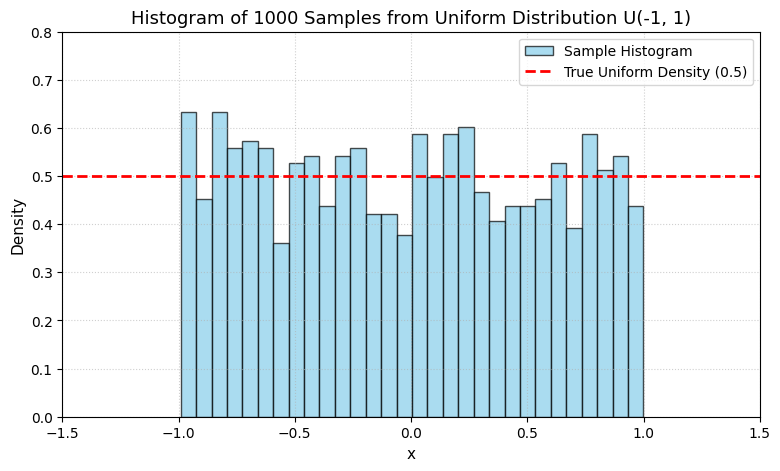

In [2]:
# Number of samples
n_samples = 1000

# Sample 1000 points from Uniform(-1, 1)
samples = np.random.uniform(-1, 1, n_samples)

# Plot sample histogram
plt.figure(figsize=(9, 5))
plt.hist(samples, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='Sample Histogram')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='True Uniform Density (0.5)')
plt.title('Histogram of 1000 Samples from Uniform Distribution U(-1, 1)', fontsize=13)
plt.xlabel('x', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.xlim(-1.5, 1.5)
plt.ylim(0, 0.8)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Part B: Parzen Window Density Estimation (Gaussian Kernel)

The Parzen window estimator using a standard Gaussian kernel is defined as:
$$ p(x) = \frac{1}{N h} \sum_{i=1}^{N} \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{1}{2} \left(\frac{x - x_i}{h}\right)^2 \right) $$

We evaluate the estimation across bandwidth values $h \in \{0.1, 0.5, 1.0, 2.0\}$.

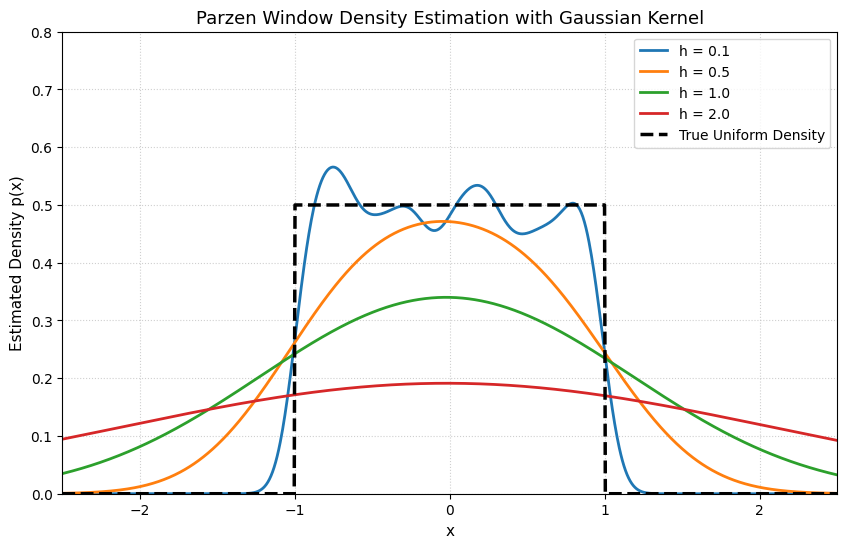

In [3]:
def gaussian_kernel(u):
    """Standard Normal Gaussian Kernel."""
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def parzen_window_estimation(samples, x_grid, h):
    """Vectorized Parzen window density estimation with Gaussian kernel."""
    u = (x_grid[:, np.newaxis] - samples[np.newaxis, :]) / h
    kernel_vals = gaussian_kernel(u)
    return np.sum(kernel_vals, axis=1) / (len(samples) * h)

# Extended evaluation range to observe boundary effects
x_grid = np.linspace(-2.5, 2.5, 1000)
true_density = np.where((x_grid >= -1) & (x_grid <= 1), 0.5, 0.0)

h_values = [0.1, 0.5, 1.0, 2.0]

plt.figure(figsize=(10, 6))
for h in h_values:
    estimated_density = parzen_window_estimation(samples, x_grid, h)
    plt.plot(x_grid, estimated_density, label=f'h = {h}', linewidth=2)

plt.plot(x_grid, true_density, 'k--', label='True Uniform Density', linewidth=2.5)
plt.title('Parzen Window Density Estimation with Gaussian Kernel', fontsize=13)
plt.xlabel('x', fontsize=11)
plt.ylabel('Estimated Density p(x)', fontsize=11)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 0.8)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Analysis of Parzen Window Estimation Results:

- **Small Bandwidth ($h = 0.1$):** High variance and low bias. The estimate captures the boundaries at $x = \pm 1$ reasonably well, but exhibits high spikiness and overfitting to local sample variations inside $[-1, 1]$.
- **Moderate Bandwidth ($h = 0.5$):** Balanced trade-off between variance and bias. It smooths out random ripples inside the interval while moderately rounding the sharp step transitions at the edges.
- **Large Bandwidth ($h = 1.0, 2.0$):** High bias and low variance (over-smoothing). As $h$ increases, the peak density drops significantly below $0.5$, sharp edge discontinuities disappear completely, and probability density leaks far outside $[-1, 1]$.

## Part C: K-Nearest Neighbors (KNN) Density Estimation

The 1D KNN density estimator at point $x$ is defined as:
$$ p(x) = \frac{k}{N \cdot V} = \frac{k}{2 \cdot N \cdot R_k(x)} $$
where $R_k(x)$ is the distance from $x$ to its $k$-th nearest neighbor, and $V = 2 R_k(x)$ represents the 1D volume (cell length).

We evaluate the estimation for $k \in \{1, 5, 20, 50\}$.

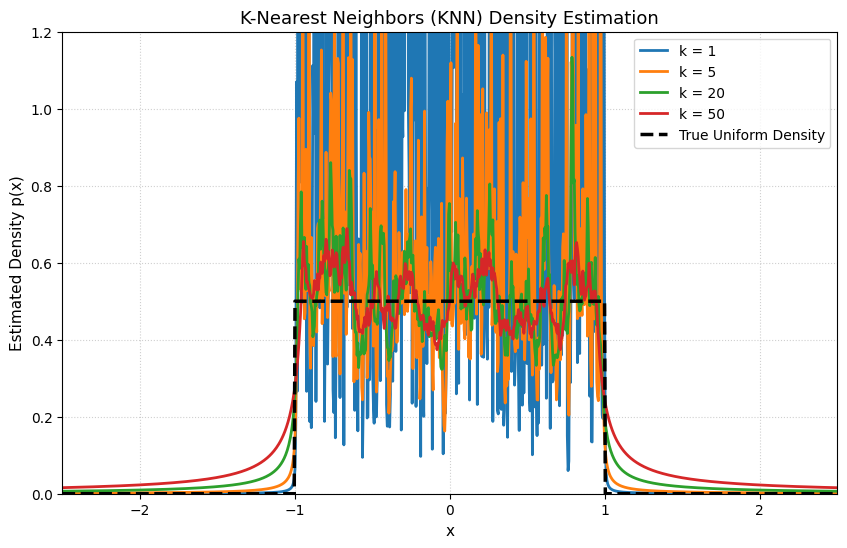

In [4]:
def knn_density_estimation(samples, x_grid, k):
    """Vectorized 1D KNN density estimation."""
    distances = np.abs(x_grid[:, np.newaxis] - samples[np.newaxis, :])
    distances_sorted = np.sort(distances, axis=1)
    r_k = distances_sorted[:, k - 1]
    volume = 2.0 * r_k
    volume = np.maximum(volume, 1e-10)  # Avoid division by zero
    return k / (len(samples) * volume)

k_values = [1, 5, 20, 50]

plt.figure(figsize=(10, 6))
for k in k_values:
    estimated_density = knn_density_estimation(samples, x_grid, k)
    plt.plot(x_grid, estimated_density, label=f'k = {k}', linewidth=2)

plt.plot(x_grid, true_density, 'k--', label='True Uniform Density', linewidth=2.5)
plt.title('K-Nearest Neighbors (KNN) Density Estimation', fontsize=13)
plt.xlabel('x', fontsize=11)
plt.ylabel('Estimated Density p(x)', fontsize=11)
plt.xlim(-2.5, 2.5)
plt.ylim(0, 1.2)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Analysis of KNN Density Estimation Results:

- **Small $k$ ($k = 1$):** Extremely high variance. The estimate shows sharp infinite-like spikes at sample points and severe noise everywhere.
- **Moderate $k$ ($k = 5, 20$):** Noise decreases significantly as $k$ increases. For $k = 20$, the density inside $[-1, 1]$ stabilizes near $0.5$.
- **Large $k$ ($k = 50$):** Provides a smooth estimate inside $(-1, 1)$, but produces heavy tails outside $[-1, 1]$. Because $R_k(x)$ grows linearly with distance outside the data support, $p(x) \propto 1/|x|$ decays slowly, leaking density far beyond the actual bounds.

---

### Comparative Summary: Parzen vs. KNN
- **Volume vs. Count Adaptation:** Parzen windows fix the volume ($h$) and count points, yielding smooth estimates with Gaussian kernels. KNN fixes the point count ($k$) and adapts the volume ($R_k$), leading to local adaptivity but non-differentiable step shapes and heavy-tailed decay.
- **Boundary Bias:** Both non-parametric methods struggle with step discontinuities at boundaries ($x = \pm 1$).